In [3]:
import os
from datetime import datetime
import pickle
import random
import math
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MaxAbsScaler, MinMaxScaler

import torch
import torch.nn as nn
import torch.nn.functional as F

os.makedirs("models", exist_ok=True)
os.makedirs("ensemble_models", exist_ok=True)

def set_all_seeds(seed):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)

seed = 0
set_all_seeds(seed)

In [4]:
df = pd.read_csv(r"C:\Users\bedla\Documents\Ausbildung_Informatik\1_Praktikum\Praktikum_Daten-_und_Prozessanalyse\energy_trading\PyCharm_Notebook\Udemy - From_1K_to_4K\Data\BTCUSDT-15m-data.csv")
print(df)

                  timestamp      open_time       open       high        low  \
0       2017-08-17 04:00:00  1502942400000    4261.48    4280.56    4261.48   
1       2017-08-17 04:15:00  1502943300000    4261.48    4270.41    4261.32   
2       2017-08-17 04:30:00  1502944200000    4280.00    4310.07    4267.99   
3       2017-08-17 04:45:00  1502945100000    4310.07    4313.62    4291.37   
4       2017-08-17 05:00:00  1502946000000    4308.83    4328.69    4304.31   
...                     ...            ...        ...        ...        ...   
275995  2025-07-07 00:00:00  1751846400000  109203.85  109273.07  109103.19   
275996  2025-07-07 00:15:00  1751847300000  109273.07  109288.02  108972.69   
275997  2025-07-07 00:30:00  1751848200000  109004.81  109037.82  108829.17   
275998  2025-07-07 00:45:00  1751849100000  108847.17  108922.00  108800.01   
275999  2025-07-07 01:00:00  1751850000000  108823.07  108823.08  108679.75   

            close     volume     close_time      qu

**Check missing values**

In [5]:
print(df.isnull())
print(f"Counts how many missing values there are in each column: {df.isnull().sum()}")
print(f"Total missing values: {df.isnull().sum().sum()}")

        timestamp  open_time   open   high    low  close  volume  close_time  \
0           False      False  False  False  False  False   False       False   
1           False      False  False  False  False  False   False       False   
2           False      False  False  False  False  False   False       False   
3           False      False  False  False  False  False   False       False   
4           False      False  False  False  False  False   False       False   
...           ...        ...    ...    ...    ...    ...     ...         ...   
275995      False      False  False  False  False  False   False       False   
275996      False      False  False  False  False  False   False       False   
275997      False      False  False  False  False  False   False       False   
275998      False      False  False  False  False  False   False       False   
275999      False      False  False  False  False  False   False       False   

        quote_av  trades  tb_base_av  t

**Split data**

In [6]:
train_end_idx = 240_000

df_train = df.iloc[:train_end_idx].copy()
df_test = df.iloc[train_end_idx:].copy()

df_test.reset_index(drop=True, inplace=True)

print(f"Length of df_train: {len(df_train)}")
print(f"Length of df_test: {len(df_test)}")

Length of df_train: 240000
Length of df_test: 36000


**Building Meaningful Features**

In [7]:
def build_features(opens, highs, lows, closes, volumes, train_scalers=None):

    # Build features
    feature1 = (closes - opens) / opens
    feature2 = (highs - opens) / opens
    feature3 = (highs - closes) / closes
    feature4 = (lows - opens) / opens
    feature5 = (lows - closes) / closes
    feature6 = (highs - lows) / opens
    feature7 = (highs - lows) / closes
    feature8 = volumes

    # Stack features
    features = [
        feature1,
        feature2,
        feature3,
        feature4,
        feature5,
        feature6,
        feature7,
        feature8,
    ]
    num_features = len(features)
    scaled_fts = []

    if train_scalers is None:
        train_scalers = [MaxAbsScaler() for _ in range(num_features)]
        is_train = True
    else:
        is_train = False

    for i in range(num_features):
        # Get train scaler
        scaler = train_scalers[i]
        if is_train:
            # Scaler -> Fit -> Train dataset
            scaled_ft = scaler.fit_transform(features[i].reshape(-1, 1))
            # Save the train scaler in a list
        elif not is_train:
            # Scaler -> NOT Fit -> Test dataset
            scaled_ft = scaler.transform(features[i].reshape(-1, 1))

        # Update list of SCALED features
        scaled_fts.append(scaled_ft.flatten())

    # Stack features
    scaled_features = np.stack(scaled_fts, axis=-1)

    # Get num. features
    num_features = scaled_features.shape[-1]
    return scaled_features, num_features, train_scalers

**Preprocess data**

In [8]:
def preprocess_data(seq_len, df, train_scalers=None):
    m = len(df)

    opens = np.array(df['open'].values)
    highs = np.array(df['high'].values)
    lows = np.array(df['low'].values)
    closes = np.array(df['close'].values)
    volumes = np.array(df['volume'].values)

    # Build features
    features, num_features, train_scalers = build_features(opens, highs, lows, closes, volumes, train_scalers)

    # Calculate number of samples
    num_samples = m - seq_len

    # Create storage for inputs & targets
    X = np.zeros([num_samples, seq_len, num_features], dtype=np.float32)
    Y = np.zeros([num_samples, num_features], dtype=np.float32)

    # Create samples (X, Y)
    for i in range(num_samples):
        X[i] = features[i : i+seq_len]
        Y[i] = features[i+seq_len : i+seq_len+1]

    # Fix alignment
    opens = np.array(opens[seq_len:])
    closes = np.array(closes[seq_len:])

    return X, Y, num_features, opens, closes, train_scalers

In [9]:
# Sequence Length
seq_len = 96

# Preprocess data
X_train, Y_train, num_features, _, _, train_scalers = preprocess_data(seq_len, df_train)
X_test, Y_test, num_features, backtest_opens, backtest_closes, _ = preprocess_data(seq_len, df_test, train_scalers)


In [10]:
m_train = X_train.shape[0]
m_test = X_test.shape[0]
print(f"m_train: {m_train}")
print(f"m_test: {m_test}")
print(f"X_train shape: {X_train.shape}")
print(f"Y_train shape: {Y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Y_test shape: {Y_test.shape}")

m_train: 239904
m_test: 35904
X_train shape: (239904, 96, 8)
Y_train shape: (239904, 8)
X_test shape: (35904, 96, 8)
Y_test shape: (35904, 8)


**Transform data to Torch Tensor**

In [11]:
device = torch.device("cuda:0" if torch.cuda.is_available() else 'cpu')
print("my deive: ", device)

X_train = torch.from_numpy(X_train.astype(np.float32)).to(device, dtype=torch.float32)
Y_train = torch.from_numpy(Y_train.astype(np.float32)).to(device, dtype=torch.float32)

X_test = torch.from_numpy(X_test.astype(np.float32)).to(device, dtype=torch.float32)
Y_test = torch.from_numpy(Y_test.astype(np.float32)).to(device, dtype=torch.float32)

Y_pred_test = torch.zeros([m_test, num_features], device=device, dtype=torch.float32)

my deive:  cpu


**Build model**

In [12]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv1d(
            in_channels=num_features,
            out_channels=32,
            kernel_size=3,
            padding=1,
            stride=1
        )
        self.act1 = nn.GELU()

        self.conv2 = nn.Conv1d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1,
            stride=1
        )
        self.act2 = nn.GELU()

        self.fc_out = nn.Linear(64, num_features)

    def forward(self, x):
        x = x.permute(0, 2, 1)   # (batch, num_features, seq_len)
        x = self.conv1(x)        # (batch, 32, seq_len)
        x = self.act1(x)
        x = self.conv2(x)        # (batch, 32, seq_len)
        x = self.act2(x)
        x = x.permute(0, 2, 1)   # (batch, seq_len, num_features)

        x = x[:, -1, :]

        x = self.fc_out(x)       # (batch, num_features)
        return x

In [13]:
MODELS_INFOS = [
    {"paths":
     [
        r"/content/ensemble_models/YOUR_MODEL_NAME.pt",
        # Add more models here ...
      ],
     "architecture": Model},
]

all_actions = [] # List to hold all actions from each model

for model_info in MODELS_INFOS:
    model_paths = model_info["paths"]
    architecture = model_info["architecture"]

    for model_path in model_paths:
        # Initialize model
        model = architecture()

        # Load trained weights
        model.load_state_dict(torch.load(model_path, map_location=torch.device(device)))

        with torch.no_grad():
            model.eval()
            Y_pred_test = model(X_test) # Forward prop

        Y_pred_test_cpu = Y_pred_test.detach().cpu().numpy()
        actions = Y_pred_test_cpu[:, 0] > 0
        all_actions.append(actions)

# ===================== Backtest =====================
equities = []    # Store equity (account value) over time
pos_size = 1000  # Fixed position size ($1000 per trade)
equity = 1000    # Starting capital
correct_pred = 0 # Initialize correct prediction

actions = []

for i in range(len(X_test)-1):
    curr_open = backtest_opens[i]   # the price we enter at.
    curr_close = backtest_closes[i] # the price we exit at.

    combined_actions = []
    for acts in all_actions:
        combined_actions.append(acts[i])

    if combined_actions.count(1) > combined_actions.count(0):
        curr_action = 1
    elif combined_actions.count(1) < combined_actions.count(0):
        curr_action = 0

    # Calculate percentage price change
    pct_change = (curr_close - curr_open) / curr_open

    # Profit or loss in dollars
    pnl = np.abs(pos_size * pct_change)

    # Update equity depending on action and price move
    if curr_action == 1:     # Long position (Buy side)
        if pct_change > 0:
            equity += pnl    # Price up → profit
            correct_pred += 1
        elif pct_change < 0:
            equity -= pnl    # Price down → loss

    elif curr_action == 0:   # Short position
        if pct_change > 0:
            equity -= pnl    # Price up → loss
        elif pct_change < 0:
            equity += pnl    # Price down → profit
            correct_pred += 1

    equities.append(equity) # Save current equity
    actions.append(curr_action)
# ========================================================


# Calculate percentage accuracy
accuracy = correct_pred / len(X_test) * 100






FileNotFoundError: [Errno 2] No such file or directory: '/content/ensemble_models/YOUR_MODEL_NAME.pt'

Result: Equity: 1867, Sharpe Ratio 0.0106, Drawdown 27.03%


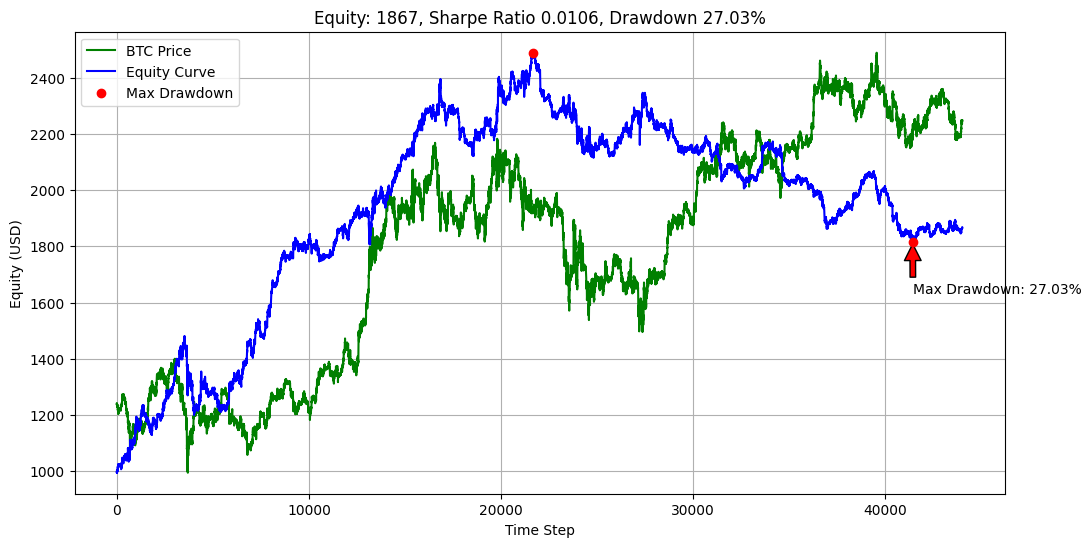

In [ ]:
# Calculate max drawdown
def calculate_max_drawdown(equities):
    # Convert to numpy array for vectorized operations
    equity = np.array(equities)

    # Calculate cumulative maximum (peak equity)
    peak = np.maximum.accumulate(equity)

    # Drawdown: (Peak - Current) / Peak
    drawdown = (peak - equity) / peak

    # Index of maximum drawdown
    max_dd_idx = np.argmax(drawdown)

    # Find the peak before the maximum drawdown
    peak_idx = np.argmax(equity[:max_dd_idx + 1])

    return {
        "max_drawdown": drawdown[max_dd_idx],
        "peak_index": peak_idx,
        "trough_index": max_dd_idx,
        "peak_value": equity[peak_idx],
        "trough_value": equity[max_dd_idx]
    }

# Calculate Sharpe Ratio
def calculate_sharpe_ratio(equities):
    # Step 1: Compute 15-minute returns
    returns = []
    for i in range(1, len(equities)):
        ret = (equities[i] - equities[i-1]) / equities[i-1]
        returns.append(ret)

    # Step 2: Mean return
    mean_return = np.mean(returns)

    # Step 3: Standard deviation
    std_dev = np.std(returns, ddof=1)

    # Step 4: Sharpe Ratio (assuming risk-free rate = 0)
    sharpe_ratio = mean_return / std_dev

    sharpe_ratio = round(sharpe_ratio, 4)
    return sharpe_ratio


def plot_equity(backtest_opens, equities, result, sharpe_ratio):
    # Chart title
    chart_title = f"Equity: {equities[-1]:.0f}, Sharpe Ratio {sharpe_ratio:.4f}, Drawdown {result['max_drawdown']:.2%}"
    print(f"Result: {chart_title}")
    # Plot equity curve
    plt.figure(figsize=(12, 6))
    scaler_earned = MinMaxScaler(feature_range=(min(equities)-0.1, max(equities)+0.1))
    plt.plot(scaler_earned.fit_transform(np.array(backtest_opens).reshape(-1,1)), color='green', label='BTC Price')
    plt.plot(equities, label="Equity Curve", color="blue")
    # Highlight peak and trough of max drawdown
    plt.scatter(
        [result["peak_index"], result["trough_index"]],
        [result["peak_value"], result["trough_value"]],
        color="red",
        zorder=5,
        label="Max Drawdown"
    )
    # Annotate max drawdown
    plt.annotate(
        f"Max Drawdown: {result['max_drawdown']:.2%}",
        xy=(result["trough_index"], result["trough_value"]),
        xytext=(result["trough_index"] + 10, result["trough_value"] * 0.9),
        arrowprops=dict(facecolor="red", shrink=0.05),
        )
    plt.title(chart_title)
    plt.xlabel("Time Step")
    plt.ylabel("Equity (USD)")
    plt.legend()
    plt.grid(True)
    plt.show()
    # plt.savefig(chart_title.replace('%', '')+'.png', dpi=300)

# Calculate sharpe ratio
sharpe_ratio = calculate_sharpe_ratio(equities)

# Calculate Max DD
result = calculate_max_drawdown(equities)

# Generate the plot
plot_equity(backtest_opens, equities, result, sharpe_ratio)